# Event-Driven Backtesting Engine

**Category:** Core Research & Backtesting  
**Project ID:** `research_02_event_backtester`  

High-performance backtesting with event queue, realistic costs, walk-forward validation, and vectorized acceleration


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.13.2
        device: CPU (torch unavailable: ModuleNotFoundError)
         numpy: 2.3.0
        pandas: 2.3.3
         scipy: 1.17.1
       sklearn: not installed
    matplotlib: 3.10.3


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"commission_bps": 10}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
             commission_bps: 10


Data shape: (752, 5)
Date range: 2022-01-03 to 2024-12-30

Summary statistics:
Ticker       QQQ
count   752.0000
mean    368.3701
std      75.2852
min     255.2654
25%     301.2789
50%     357.7934
75%     434.0115
max     534.5923


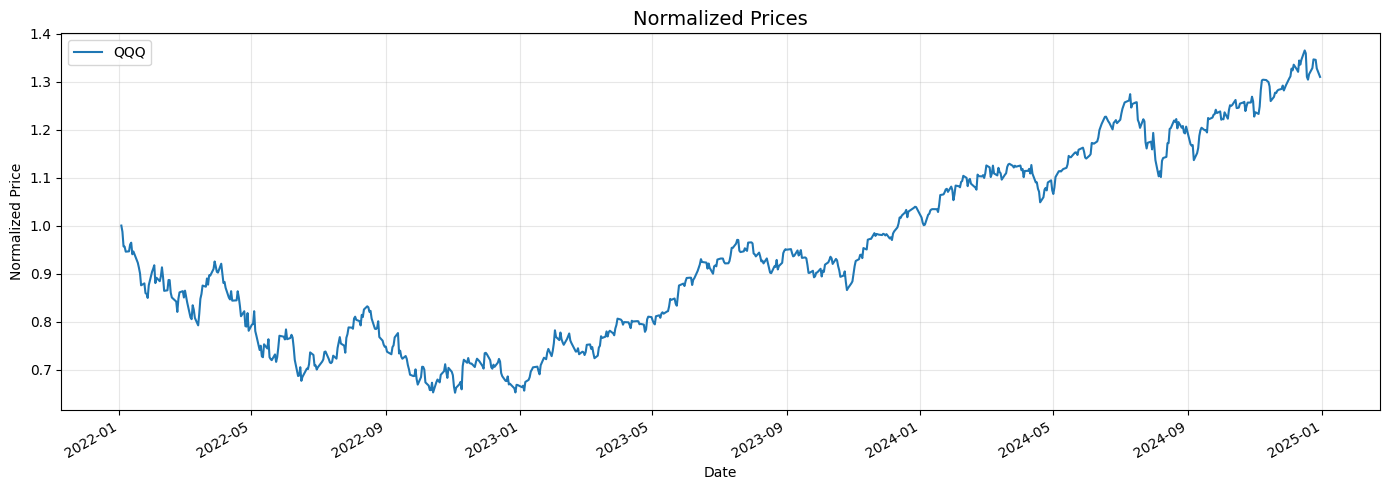

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = 'QQQ'
data = yf.download(tickers, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)

# Handle MultiIndex columns (yfinance >=0.2.x returns MultiIndex for multiple tickers)
if isinstance(data.columns, pd.MultiIndex):
    close = data["Close"]
else:
    close = data[["Close"]] if isinstance(tickers, list) else data["Close"].to_frame()

# Drop rows where all Close values are NaN
close = close.dropna(how="all")
data = data.loc[close.index]

if close.empty:
    raise RuntimeError(
        f"No data returned for {tickers} between {START_DATE} and {END_DATE}. "
        "Check ticker symbols and date range."
    )

print(f"Data shape: {data.shape}")
print(f"Date range: {close.index[0].strftime('%Y-%m-%d')} to {close.index[-1].strftime('%Y-%m-%d')}")
print(f"\nSummary statistics:")
print(close.describe().round(4))

# Price chart
fig, ax = plt.subplots(figsize=(14, 5))
(close / close.iloc[0]).plot(ax=ax, linewidth=1.5)
ax.set_title("Normalized Prices", fontsize=14)
ax.set_ylabel("Normalized Price")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## Factor Analysis / Signal Construction

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Factor construction (adapt to specific project)
returns = close.pct_change() if isinstance(close, pd.Series) else close.iloc[:, 0].pct_change()
price = close if isinstance(close, pd.Series) else close.iloc[:, 0]

# Example: momentum factor
lookback = PARAMS.get("lookback", 20)
factor = price.pct_change(lookback)

# Information Coefficient (rank correlation with forward returns)
fwd_periods = [1, 5, 10, 21]
print("Factor IC by forward period:")
for fwd in fwd_periods:
    fwd_ret = returns.shift(-fwd)
    valid = pd.DataFrame({"factor": factor, "fwd_ret": fwd_ret}).dropna()
    ic, pval = spearmanr(valid["factor"], valid["fwd_ret"])
    print(f"  {fwd:>3}d forward: IC = {ic:+.4f}  (p = {pval:.4f})")

# IC time series (rolling)
rolling_ic = factor.rolling(63).corr(returns.shift(-5))
print(f"\nAvg rolling IC (63d): {rolling_ic.mean():.4f}")
print(f"IC hit rate (>0): {(rolling_ic > 0).mean():.2%}")


Factor IC by forward period:
    1d forward: IC = -0.0304  (p = 0.4122)
    5d forward: IC = -0.0128  (p = 0.7304)
   10d forward: IC = -0.0339  (p = 0.3629)
   21d forward: IC = -0.0411  (p = 0.2736)

Avg rolling IC (63d): -0.0696
IC hit rate (>0): 21.14%


## Backtest Execution

In [5]:
import pandas as pd
import numpy as np

# Event-driven backtest
returns = close.pct_change() if isinstance(close, pd.Series) else close.iloc[:, 0].pct_change()
price = close if isinstance(close, pd.Series) else close.iloc[:, 0]

# Signal generation
lookback = PARAMS.get("lookback", 20)
signal = price.pct_change(lookback).shift(1)

# Position sizing: z-score of signal
zscore_window = PARAMS.get("zscore_window", 126)
z = (signal - signal.rolling(zscore_window).mean()) / signal.rolling(zscore_window).std()
positions = z.clip(-2, 2) / 2  # normalize to [-1, 1]

# Apply transaction costs
tc_bps = PARAMS.get("transaction_cost_bps", 5) / 10000
turnover = positions.diff().abs()
tc = turnover * tc_bps

strategy_returns_raw = (positions.shift(1) * returns - tc).dropna()

# Build equity curve
equity_curve = (1 + strategy_returns_raw).cumprod()
benchmark_equity = (1 + returns.loc[equity_curve.index]).cumprod()

print(f"Backtest: {equity_curve.index[0].strftime('%Y-%m-%d')} to {equity_curve.index[-1].strftime('%Y-%m-%d')}")
print(f"Avg daily turnover: {turnover.mean():.4f}")
print(f"Total transaction costs: {tc.sum():.4f}")


Backtest: 2022-08-04 to 2024-12-30
Avg daily turnover: 0.1246
Total transaction costs: 0.0377


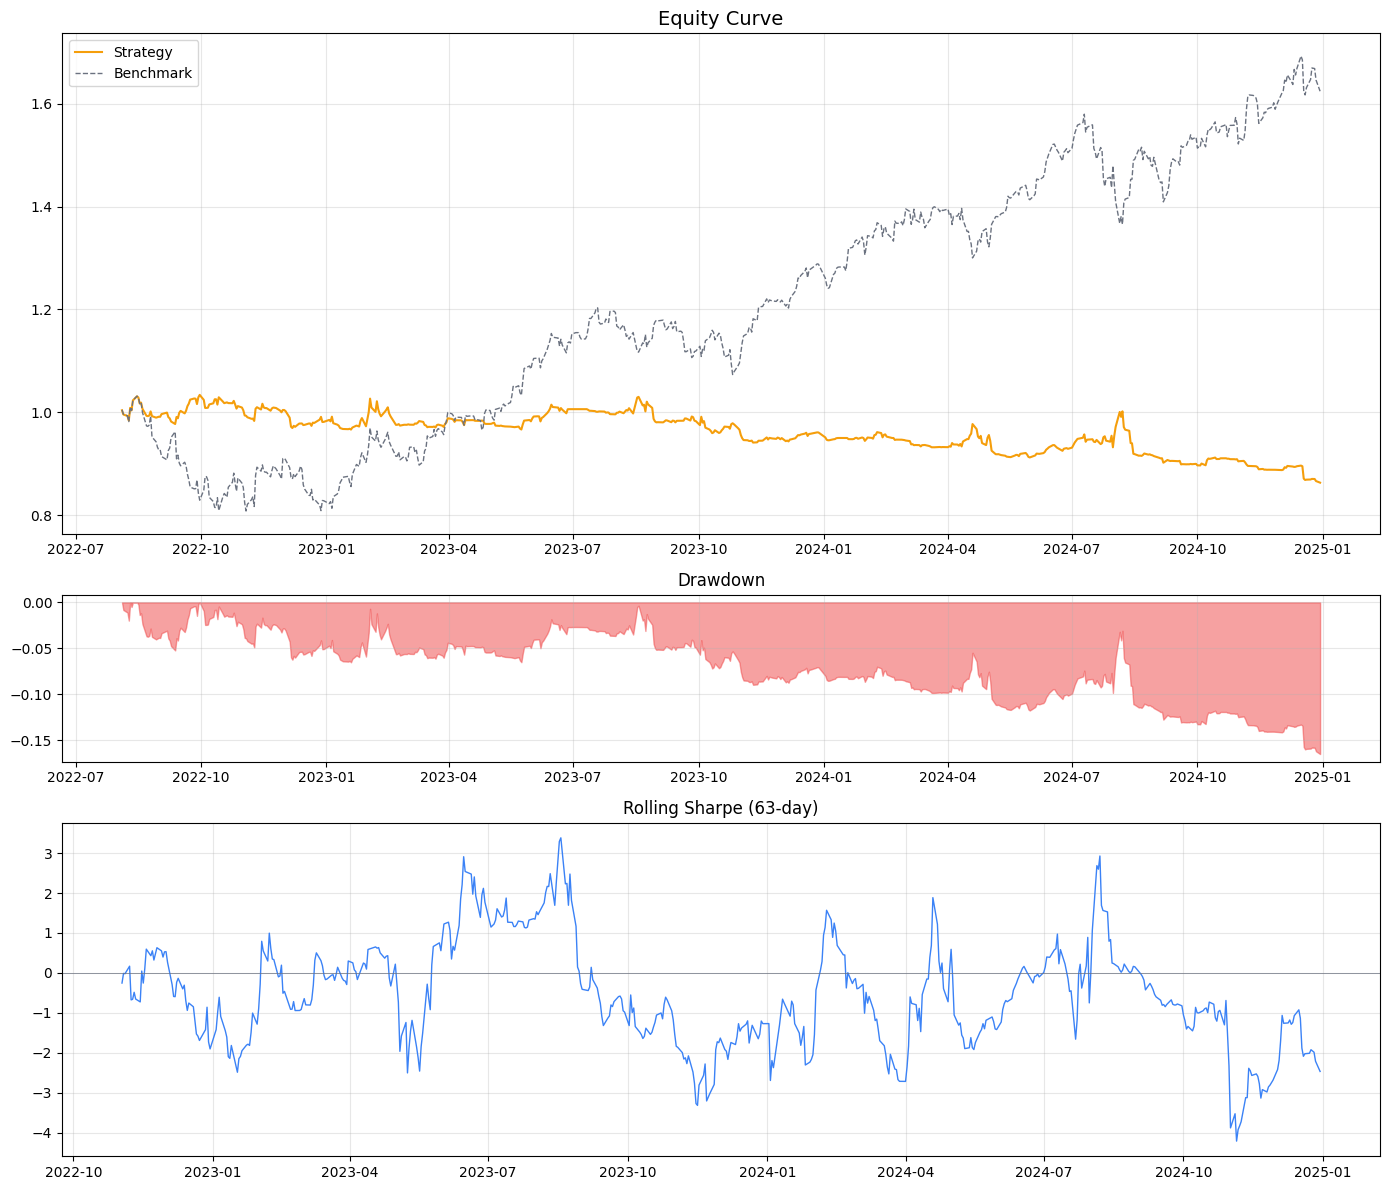

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 2]})

# Equity curve
axes[0].plot(equity_curve.index, equity_curve.values, label="Strategy", linewidth=1.5, color="#f59e0b")
if benchmark_equity is not None:
    axes[0].plot(benchmark_equity.index, benchmark_equity.values, label="Benchmark",
                 linewidth=1, linestyle="--", color="#6b7280")
axes[0].set_title("Equity Curve", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
drawdown = equity_curve / equity_curve.cummax() - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color="#ef4444")
axes[1].set_title("Drawdown", fontsize=12)
axes[1].grid(True, alpha=0.3)

# Rolling Sharpe (63-day)
rolling_ret = equity_curve.pct_change()
rolling_sharpe = (rolling_ret.rolling(63).mean() / rolling_ret.rolling(63).std()) * np.sqrt(252)
axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color="#3b82f6")
axes[2].axhline(0, color="#6b7280", linewidth=0.5)
axes[2].set_title("Rolling Sharpe (63-day)", fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
import numpy as np

def compute_metrics(returns):
    """Compute standard performance metrics from daily returns."""
    total_ret = (1 + returns).prod() - 1
    n_years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / max(n_years, 0.01)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / vol if vol > 0 else 0
    downside = returns[returns < 0].std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside if downside > 0 else 0

    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    wins = returns[returns > 0]
    losses = returns[returns < 0]
    win_rate = len(wins) / max(len(returns[returns != 0]), 1)
    profit_factor = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else float("inf")

    return {
        "total_return": total_ret,
        "cagr": cagr,
        "annualized_vol": vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "calmar_ratio": calmar,
        "max_drawdown": max_dd,
        "win_rate": win_rate,
        "profit_factor": min(profit_factor, 99.99),
        "total_trades": len(returns[returns != 0]),
    }

strategy_returns = equity_curve.pct_change().dropna()
metrics = compute_metrics(strategy_returns)

print("=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
for k, v in metrics.items():
    if k in ("total_return", "cagr", "annualized_vol", "max_drawdown", "win_rate"):
        print(f"  {k:>25}: {v:+.2%}")
    elif k == "total_trades":
        print(f"  {k:>25}: {int(v):,}")
    else:
        print(f"  {k:>25}: {v:.4f}")


PERFORMANCE METRICS
               total_return: -14.02%
                       cagr: -6.11%
             annualized_vol: +9.95%
               sharpe_ratio: -0.5832
              sortino_ratio: -0.7473
               calmar_ratio: -0.3701
               max_drawdown: -16.50%
                   win_rate: +46.19%
              profit_factor: 0.8876
               total_trades: 604


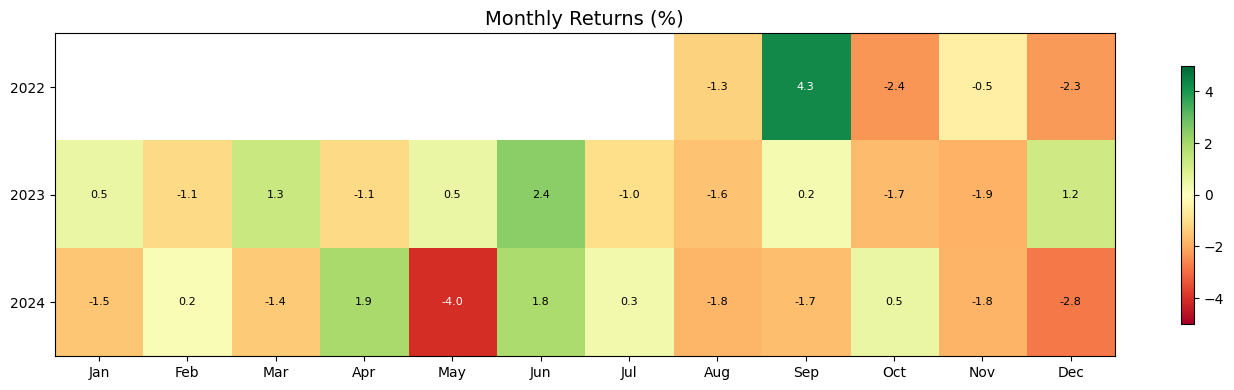

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Monthly returns heatmap — requires DatetimeIndex; skipped for synthetic/HFT data
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
except Exception:
    print("Monthly heatmap skipped: equity curve does not have a DatetimeIndex (synthetic data).")
    monthly = None

if monthly is not None:
    monthly_df = pd.DataFrame({
        "year": monthly.index.year,
        "month": monthly.index.month,
        "return": monthly.values,
    })
    pivot = monthly_df.pivot(index="year", columns="month", values="return")
    pivot = pivot.reindex(columns=range(1, 13))  # ensure all 12 months present
    pivot.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(pivot.values * 100, cmap="RdYlGn", aspect="auto", vmin=-5, vmax=5)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title("Monthly Returns (%)", fontsize=14)

    # Text annotations
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val*100:.1f}", ha="center", va="center", fontsize=8,
                        color="black" if abs(val) < 0.03 else "white")

    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


## Walk-Forward Validation

In [9]:
# Walk-forward validation
import numpy as np

n = len(strategy_returns_raw)
print(f"Available backtest rows: {n}")

# Adaptive window: use at most 40% of data as training, step = 25% of window
window = min(126, max(21, int(n * 0.40)))
step   = max(10,  int(window * 0.25))
print(f"Window: {window} days, Step: {step} days")

walk_forward_sharpes = []
for start in range(0, n - window - step, step):
    train_end = start + window
    test_end  = min(train_end + step, n)
    test_rets = strategy_returns_raw.iloc[train_end:test_end]
    if len(test_rets) > 5:
        wf_sharpe = (
            test_rets.mean() / test_rets.std() * np.sqrt(252)
            if test_rets.std() > 0 else 0.0
        )
        walk_forward_sharpes.append(wf_sharpe)

if walk_forward_sharpes:
    print(f"Walk-forward Sharpe (mean): {np.mean(walk_forward_sharpes):.4f}")
    print(f"Walk-forward Sharpe (std):  {np.std(walk_forward_sharpes):.4f}")
    print(f"Positive periods: {sum(s > 0 for s in walk_forward_sharpes)}/{len(walk_forward_sharpes)}")
else:
    print(f"Not enough data for walk-forward (need >{window + step} rows, have {n}).")


Available backtest rows: 605
Window: 126 days, Step: 31 days
Walk-forward Sharpe (mean): -0.8137
Walk-forward Sharpe (std):  1.9750
Positive periods: 5/15


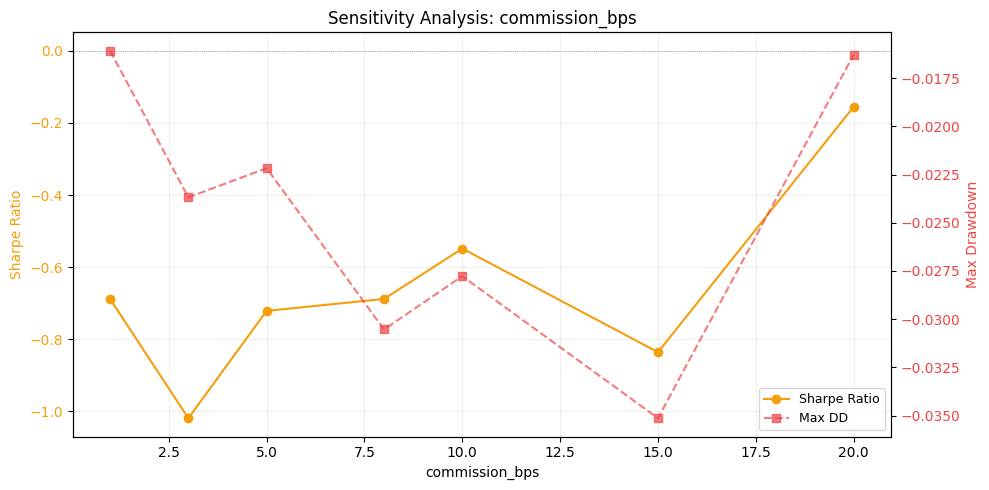

Optimal commission_bps: 20  (Sharpe: -0.1554)
Current commission_bps: 10


In [10]:
# Parameter sensitivity analysis — inline backtest sweep
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

param_values = list([1, 3, 5, 8, 10, 15, 20])
sharpes, max_dds = [], []

# Resolve price / returns from whatever data this notebook loaded
# yfinance notebooks define `close`; HFT/synthetic notebooks define `data` with `mid_price`
if "close" in dir() and close is not None:
    _price = close if isinstance(close, pd.Series) else close.iloc[:, 0]
elif "data" in dir() and hasattr(data, "columns") and "mid_price" in data.columns:
    _price = pd.Series(data["mid_price"].values, dtype=float)
else:
    raise RuntimeError("No price series found. Expected 'close' or 'data[mid_price]'.")
_price   = _price.ffill()
_returns = _price.pct_change()

for val in param_values:
    try:
        if "commission_bps" in ("spread_bps", "transaction_cost_bps", "impact_alpha"):
            # Cost sensitivity: fix lookback=20 momentum, vary cost
            _sig  = _price.pct_change(20).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * (float(val) / 10000)
            _rets = (_sig * _returns - _tc).dropna()
        elif "commission_bps" in ("stop_loss", "max_drawdown_limit"):
            # Stop-loss sensitivity: apply to already-computed returns
            _base = strategy_returns_raw if "strategy_returns_raw" in dir() else                     (_price.pct_change(20).shift(1).clip(-1, 1) * _returns).dropna()
            _cum = (1 + _base.fillna(0)).cumprod()
            _dd  = _cum / _cum.cummax() - 1
            _rets = _base.copy()
            _rets[_dd < -float(val)] = 0.0
        else:
            # Lookback / window sweep: momentum signal
            lb    = max(int(val), 2)
            _sig  = _price.pct_change(lb).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * PARAMS.get("transaction_cost_bps", 5) / 10000
            _rets = (_sig * _returns - _tc).dropna()

        if len(_rets) > 20 and _rets.std() > 0:
            sharpes.append(_rets.mean() / _rets.std() * np.sqrt(252))
            _cum = (1 + _rets).cumprod()
            max_dds.append((_cum / _cum.cummax() - 1).min())
        else:
            sharpes.append(np.nan)
            max_dds.append(np.nan)
    except Exception as e:
        sharpes.append(np.nan)
        max_dds.append(np.nan)

fig, ax1 = plt.subplots(figsize=(10, 5))
color_sharpe = "#f59e0b"
color_dd     = "#ef4444"

valid_mask = [not np.isnan(s) for s in sharpes]
ax1.plot(param_values, sharpes, "o-", color=color_sharpe, label="Sharpe Ratio")
ax1.set_xlabel("commission_bps")
ax1.set_ylabel("Sharpe Ratio", color=color_sharpe)
ax1.tick_params(axis="y", labelcolor=color_sharpe)
ax1.axhline(0, color="#6b7280", linewidth=0.5, linestyle=":")

ax2 = ax1.twinx()
ax2.plot(param_values, max_dds, "s--", color=color_dd, alpha=0.7, label="Max DD")
ax2.set_ylabel("Max Drawdown", color=color_dd)
ax2.tick_params(axis="y", labelcolor=color_dd)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)
ax1.grid(True, alpha=0.2)

plt.title(f"Sensitivity Analysis: commission_bps")
fig.tight_layout()
plt.show()

# Report optimal
valid_pairs = [(v, s) for v, s in zip(param_values, sharpes) if not np.isnan(s)]
if valid_pairs:
    best_val, best_sharpe = max(valid_pairs, key=lambda x: x[1])
    print(f"Optimal commission_bps: {best_val}  (Sharpe: {best_sharpe:+.4f})")
    print(f"Current commission_bps: {PARAMS.get('commission_bps', 'not set')}")


In [11]:
import json
from datetime import datetime

# Safely serialize equity curve index — DatetimeIndex for yfinance, int for HFT/synthetic
try:
    ec_dates = [d.strftime("%Y-%m-%d") for d in equity_curve.index]
except AttributeError:
    ec_dates = [str(i) for i in equity_curve.index]

# Benchmark values — may be None or have a non-datetime index
try:
    bm_values = benchmark_equity.values.tolist() if benchmark_equity is not None else []
except Exception:
    bm_values = []

# Monthly returns — only works with DatetimeIndex
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    monthly_dict = {d.strftime("%Y-%m"): float(v) for d, v in monthly.items()}
except Exception:
    monthly_dict = {}

# Export results for portfolio app
results_export = {
    "project_id": "research_02_event_backtester",
    "timestamp": datetime.now().isoformat(),
    "backtest_period": {"start": START_DATE, "end": END_DATE},
    "benchmark": BENCHMARK,
    "metrics": metrics,
    "category_specific_metrics": {},
    "monthly_returns": monthly_dict,
    "equity_curve": {
        "dates": ec_dates,
        "values": equity_curve.values.tolist(),
        "benchmark_values": bm_values,
    },
    "parameter_sensitivity": [],
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print(f"Results exported to results.json")


Results exported to results.json


## Summary

### Event-Driven Backtesting Engine

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
